In [1]:
import json
import time
import logging
import re
import fnmatch
import numpy as np
import pandas as pd
import networkx as nx
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Инициализация логгера. Не перезапускать - создастся много логгеров сразу, будут двоить/троить записи!
logger = logging.getLogger(__name__)
logger.setLevel(logging.DEBUG)

dh = logging.FileHandler('debug.log', encoding='utf-8')
dh.setLevel(logging.DEBUG)

eh = logging.FileHandler('error.log', encoding='utf-8')
eh.setLevel(logging.ERROR)

# Указываем время работы и прочую инфформацию (по дефолту бы меньше сведений было, особенно не хватало бы времени как раз)
formatter = logging.Formatter('%(asctime)s-%(name)s-%(levelname)s-%(message)s')
dh.setFormatter(formatter)
eh.setFormatter(formatter)

logger.addHandler(eh)
logger.addHandler(dh)

In [3]:
with open('vacancies_details.json', 'r', encoding='utf-8') as file:
    df = pd.read_json(file).set_index('id')
logger.debug(f"Загружен файл, итого {df.shape} строк и столбцов")
df.shape

(16195, 7)

In [4]:
def parse_salary(x):
    arr = str(x).replace('\xa0', ' ').split(" ")
    arr_idx = [i for i, s in enumerate(arr) if s.isdigit()]
    final = []
    prev=0
    token=""
    for idx in arr_idx:
        if idx == prev+1:
            prev = idx
            token = token + arr[idx]
        else:
            final.append(token)
            prev = idx
            token = arr[idx]
    if len(token)>0:
        final.append(token)
    nums = [int(el) for el in final if el.isdigit()]
    if len(nums)>0:
        return np.average(np.array(nums))
    else:
        return None

In [5]:
df["salary_parced"] = df["salary"].apply(lambda x: parse_salary(x))
logger.debug("Зарплата обработана")

In [6]:
df = df.explode("skills", ignore_index=True)
logger.debug(f"Получено {df.shape} денормализированных строк")

In [7]:
df["id"] = df["link"].apply(lambda x: str(x).split("/")[-1].split("?")[0])

In [8]:
df["id"].nunique()

5162

In [9]:
skillset = df['skills'].dropna().unique()
skillset.sort()
logger.debug(f"Итого уникальных скиллов: {len(skillset)}")

In [10]:
exceptions = {
'golang': 'Go',
'go lang': 'Go',
'py': 'Python',
'js': 'JavaScript',
'ts': 'TypeScript',
'node.js': 'JavaScript',
'nodejs': 'JavaScript',
'csharp': 'C#',
'cpp': 'C++',
'kt': 'Kotlin',
'drf': 'Django',
'rn': 'React',
'react native': 'React',
'nextjs': 'Next.js',
'nuxtjs': 'Nuxt',
'pg': 'PostgreSQL',
'sklearn': 'scikit-learn',
'tf': 'TensorFlow',
'pd': 'Pandas',
'np': 'NumPy',
'cv2': 'OpenCV',
'ws': 'WebSocket',
'junit5': 'JUnit',
}
msk = {
    'Python': 'python*',
    'Go': 'go*',
    'Java': 'java*',
    'Kotlin': 'kotlin*',
    'C++': 'c++*',
    'C': 'c',
    'TypeScript': 'type*script*',
    'JavaScript': 'java*script*',
    'Rust': 'rust*',
    'C#': 'c#',
    'PHP': 'php*',
    'Django': 'django*',
    'FastAPI': 'fastapi*',
    'Flask': 'flask*',
    'Spring Boot': 'spring*boot*',
    'Express.js': 'express*',
    'NestJS': 'nest*js*',
    'React': 'react*',
    'Vue.js': 'vue*',
    'Angular': 'angular*',
    'Next.js': 'next*',
    'Nuxt': 'nuxt*',
    'Flutter': 'flutter*',
    'Swift': 'swift*',
    'Android SDK': 'android*',
    'PostgreSQL': 'postgres*',
    'MySQL': 'mysql*',
    'MongoDB': 'mongo*',
    'SQLite': 'sqlite*',
    'SQLAlchemy': 'sqlalchemy*',
    'PyTorch': 'pytorch*',
    'TensorFlow': 'tensorflow*',
    'scikit-learn': 'scikit*',
    'Pandas': 'pandas*',
    'NumPy': 'numpy*',
    'Jupyter': 'jupyter*',
    'OpenCV': 'opencv*',
    'Hugging Face': 'hugging*face*',
    'Transformers': 'transformers*',
    'LangChain': 'langchain*',
    'REST API': 'rest*api*',
    'GraphQL': 'graphql*',
    'gRPC': 'grpc*',
    'WebSocket': 'websocket*',
    'pytest': 'pytest*',
    'JUnit': 'junit*',
    'Selenium': 'selenium*'
}

In [11]:
def map_skill(skill):
    if skill in exceptions.keys():
        return exceptions[skill]
    else:
        for key, mask in msk.items():
            if fnmatch.fnmatch(skill, mask):
                return key
    return None

In [12]:
cleaned_skills = list(set(list(exceptions.values()) + list(msk.keys())))
cleaned_skills

['NestJS',
 'WebSocket',
 'Angular',
 'Swift',
 'TensorFlow',
 'Android SDK',
 'REST API',
 'Rust',
 'MySQL',
 'PyTorch',
 'Vue.js',
 'SQLite',
 'Spring Boot',
 'Flutter',
 'PostgreSQL',
 'FastAPI',
 'Go',
 'PHP',
 'gRPC',
 'Selenium',
 'Django',
 'JavaScript',
 'Flask',
 'LangChain',
 'NumPy',
 'Transformers',
 'C#',
 'Next.js',
 'scikit-learn',
 'React',
 'Hugging Face',
 'GraphQL',
 'Pandas',
 'C++',
 'Kotlin',
 'C',
 'MongoDB',
 'pytest',
 'SQLAlchemy',
 'Java',
 'Nuxt',
 'JUnit',
 'OpenCV',
 'Express.js',
 'Jupyter',
 'Python',
 'TypeScript']

In [13]:
df["skill_mapped"] = df["skills"].apply(lambda x: map_skill(str(x).lower()))

In [14]:
df = df.drop(["skills", "salary"], axis=1)

In [15]:
df["skill_mapped"].astype(str).nunique()

48

In [16]:
df = df.drop_duplicates()
df["link"].nunique()

8956

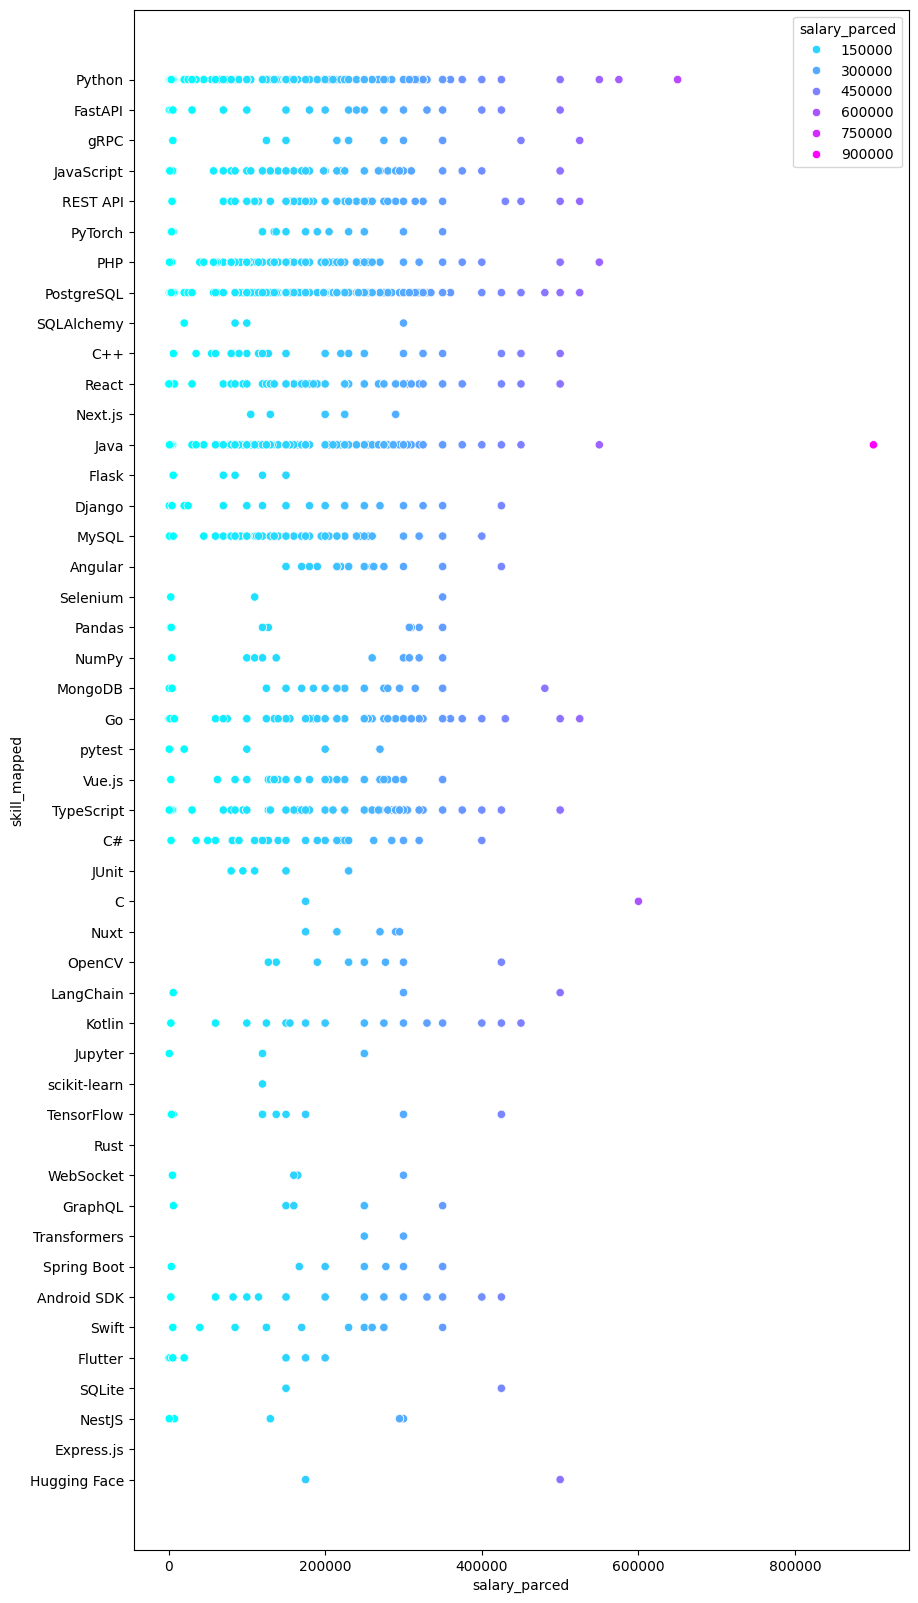

In [17]:
plt.figure(figsize=(10,20))
sns.scatterplot(df[~df["skill_mapped"].isna()], x="salary_parced", y="skill_mapped", palette="cool", hue="salary_parced")
plt.savefig("salary_scatter.png")

<Axes: ylabel='Frequency'>

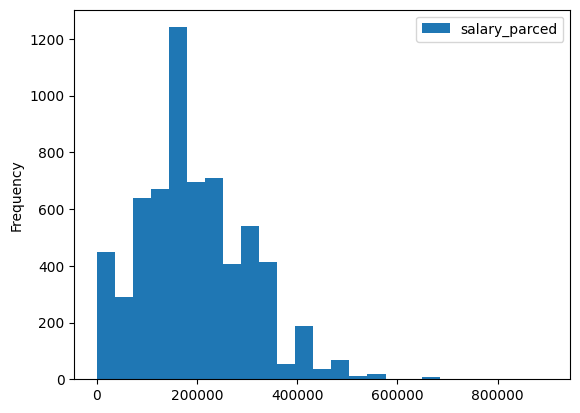

In [18]:
df[df["salary_parced"]<1000000].plot.hist(bins=25)

In [19]:
df_salary = df[(df["salary_parced"]>0) & (df["salary_parced"]<500000)].groupby(["id", "salary_parced"]).count()["skill_mapped"].reset_index()

<Axes: xlabel='skill_mapped', ylabel='salary_parced'>

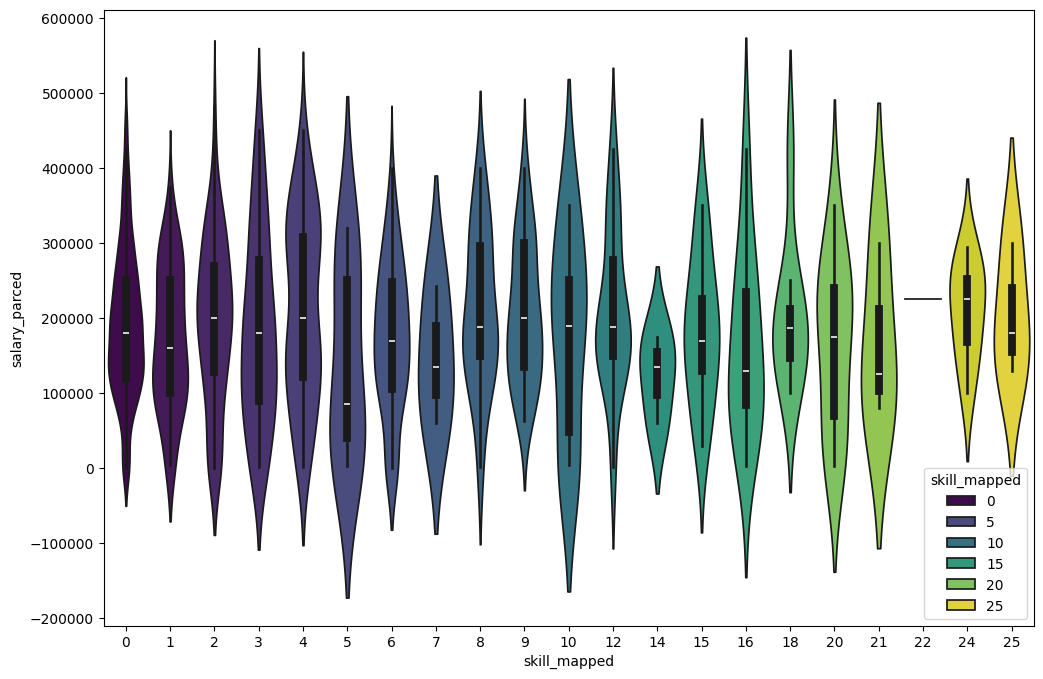

In [20]:
plt.figure(figsize=(12, 8))
sns.violinplot(data=df_salary[df_salary["skill_mapped"]<=25], x='skill_mapped', y='salary_parced', palette='viridis', hue='skill_mapped')

In [21]:
df = df.dropna(subset="skill_mapped")

In [22]:
hmap_arr = np.array([[0 for i in range(df["skill_mapped"].nunique())] for j in range(df["skill_mapped"].nunique())]) # Мы взяли просто каждый уникальный навык и сделали матрицу 
idx_map = {val: key for key, val in enumerate(df["skill_mapped"].unique())} # Ключи для матрицы (как найти индекс по значению)

In [23]:
list_grouped = np.array(df.groupby("id")["skill_mapped"].agg(list)) # Взяли просто список скиллов назад из .explode 

In [24]:
for item in list_grouped:
    for i in range(len(item)):
        for j in range(i+1, len(item)):
            if item[i] in idx_map.keys() and item[j] in idx_map.keys(): # Если в списке у вакансии есть 2 скилла - добавляем в матрицу
                hmap_arr[idx_map[item[i]]][idx_map[item[j]]]+=1
                hmap_arr[idx_map[item[j]]][idx_map[item[i]]]+=1
hmap_arr

array([[2532,  424,   76, ...,   16,    0,    5],
       [ 424,  286,    7, ...,    0,    0,    1],
       [  76,    7,  114, ...,    0,    0,    0],
       ...,
       [  16,    0,    0, ...,   66,    9,    0],
       [   0,    0,    0, ...,    9,   42,    0],
       [   5,    1,    0, ...,    0,    0,    2]], shape=(47, 47))

In [25]:
hmask = list(hmap_arr.sum(axis=1)>500) # Чистим от малых связей - полный квадрат не получится нарисовать
hmap_arr = hmap_arr[hmask][:, hmask]
hmap_keys = np.array(list(idx_map.keys()))[hmask]

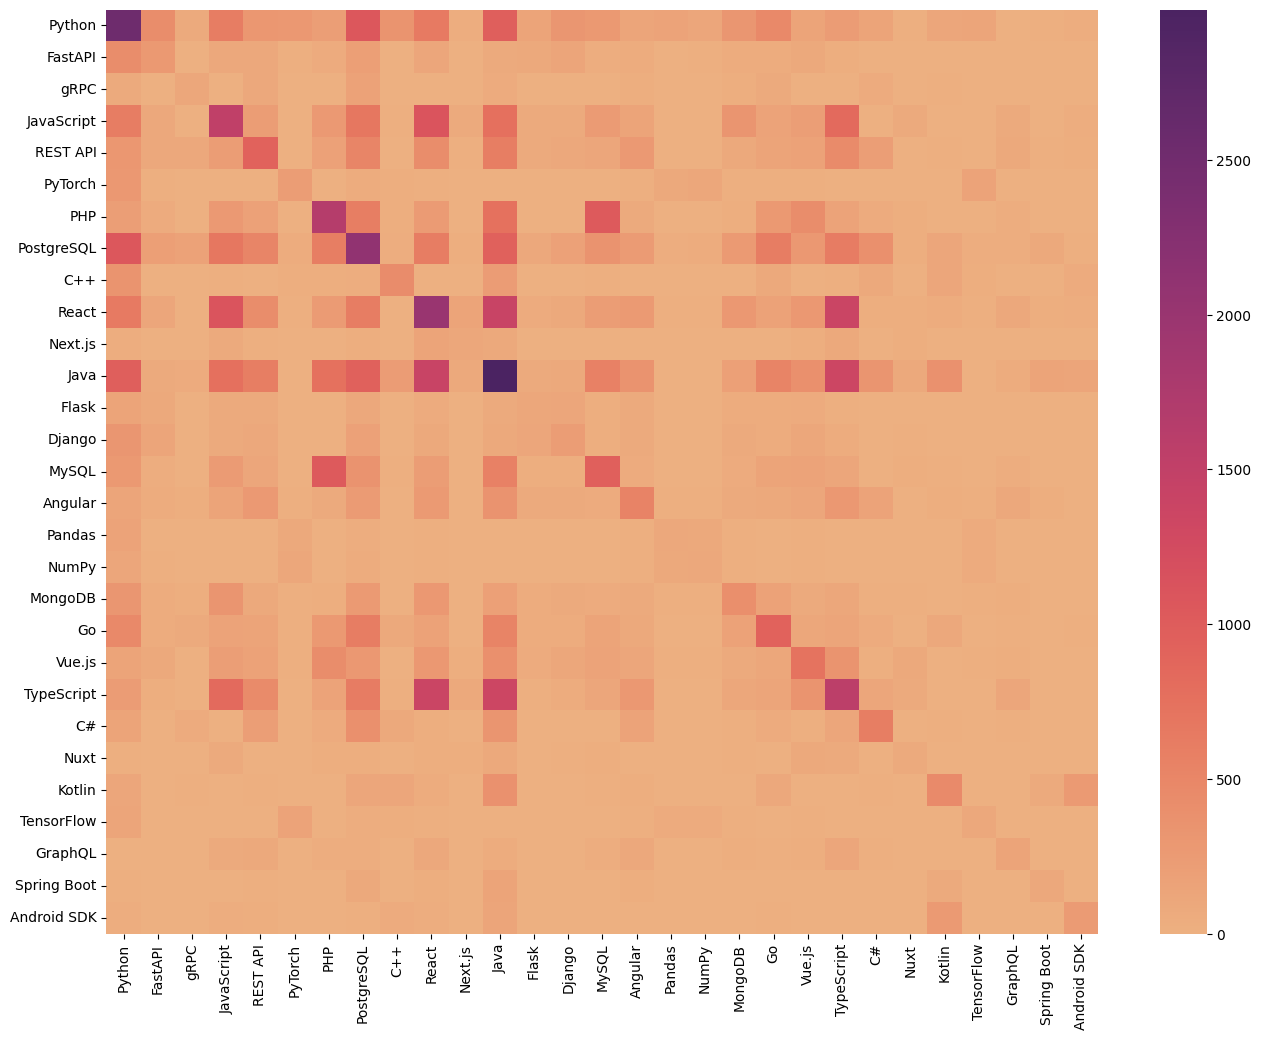

In [26]:
plt.figure(figsize=(16, 12))
sns.heatmap(pd.DataFrame(hmap_arr, index=hmap_keys, columns=hmap_keys), cmap="flare")
plt.savefig("library_occurance.png")

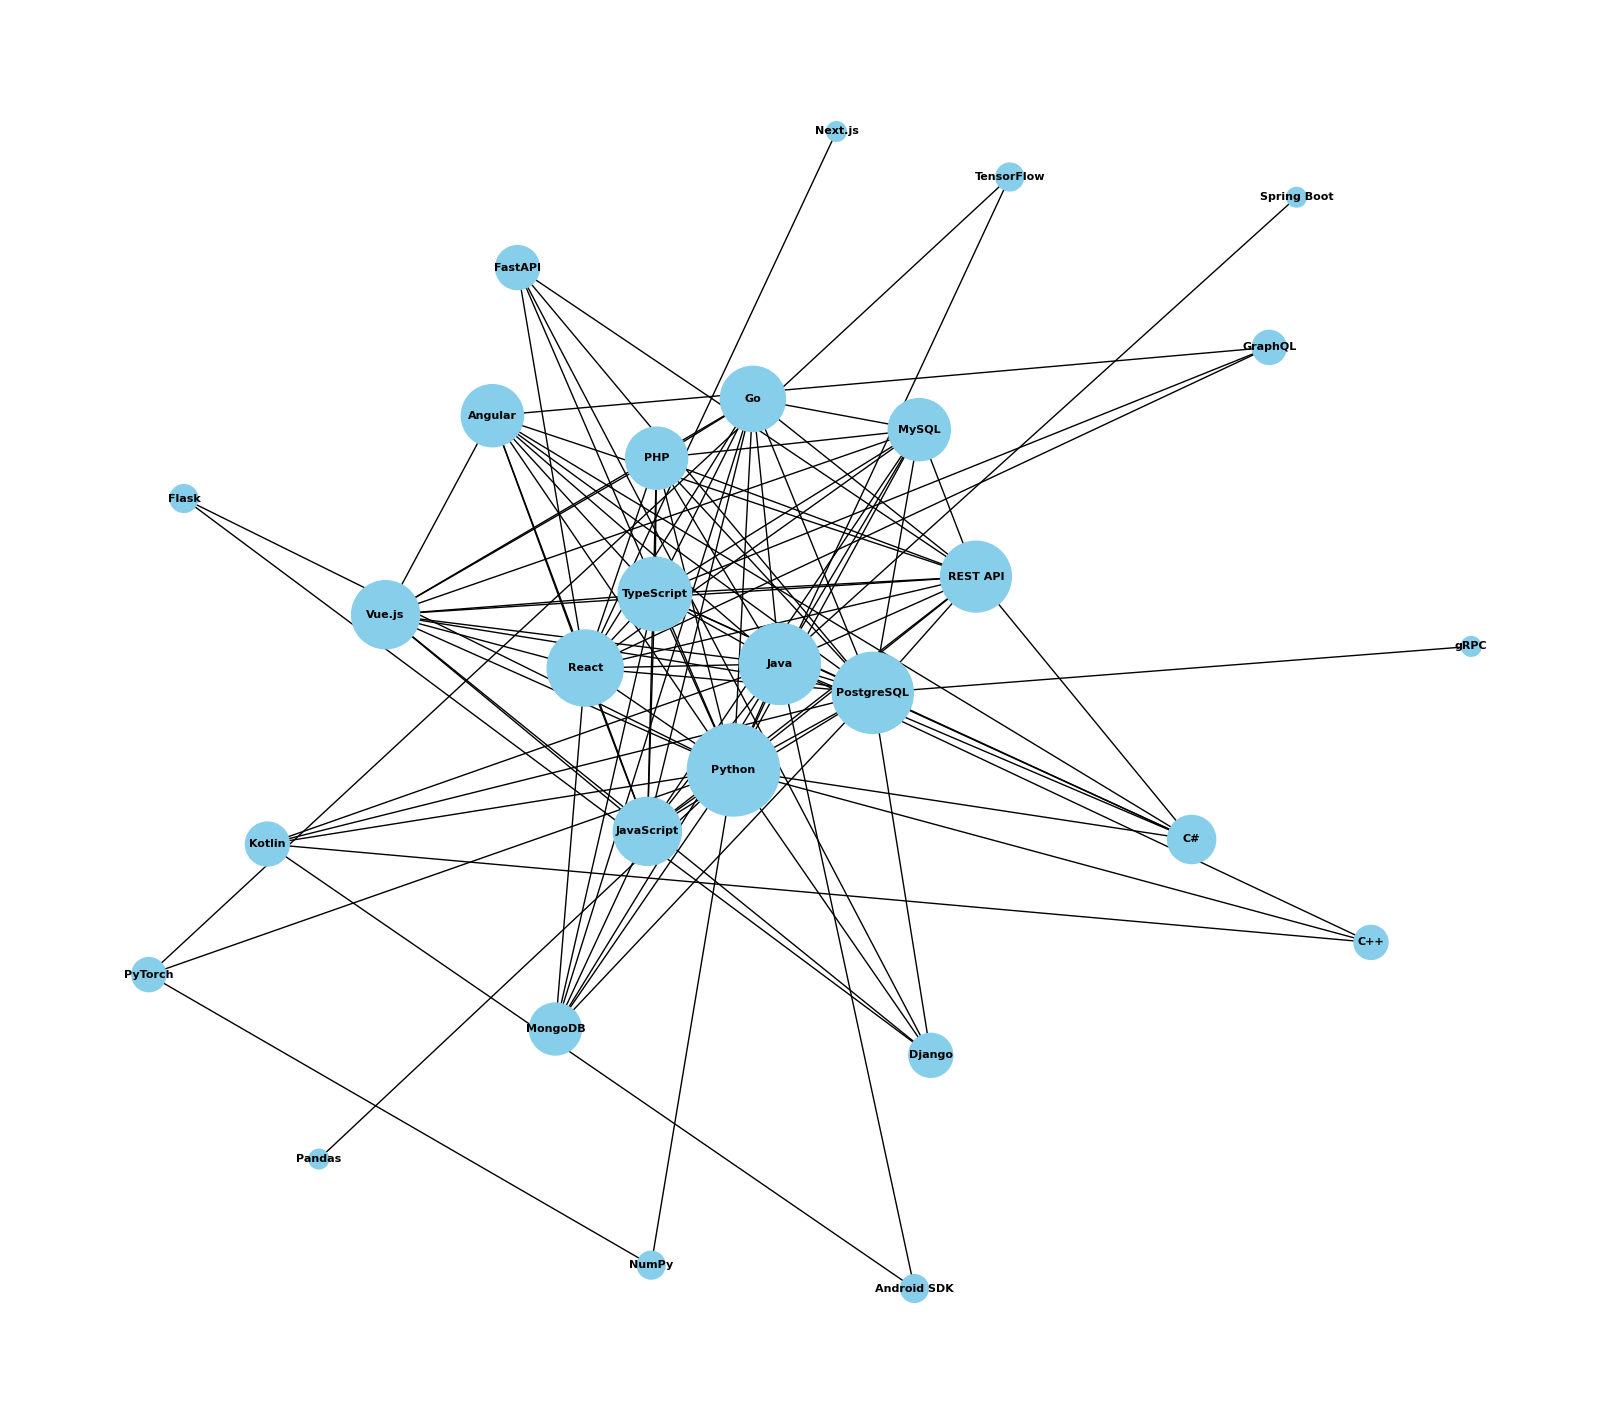

In [27]:
# https://bigdataschool.ru/blog/connected-components-in-directed-graph-with-networkx-in-colab/
# https://networkx.org/documentation/stable/tutorial.html
# https://networkx.org/documentation/stable/reference/generated/networkx.drawing.nx_pylab.draw_networkx.html#networkx.drawing.nx_pylab.draw_networkx
G = nx.Graph() # Создали граф
for i, sk_1 in enumerate(hmap_keys):
    for j, sk_2 in enumerate(hmap_keys):
        if i < j and hmap_arr[i][j] > 100:  # ставим порог хотя бы 50 вакансий чтобы брать не просто все сочетания
            G.add_edge(sk_1, sk_2, weight=hmap_arr[i][j]) # просто ребру вес добавляем пропорционально кол-ву встреч

# Визуализация
plt.figure(figsize=(16, 14))
pos = nx.spring_layout(G, k=10) # https://yandex.ru/search/?text=nx.spring_layout&lr=10743&clid=11528080 
nx.draw(G, pos, 
        node_size=[G.degree(node)*200 for node in G.nodes()],
        with_labels=True, node_color='skyblue', font_size=8, font_weight="bold")
plt.savefig('skills_network.png', dpi=300)